1. Data Cleaning
2. EDA
3. Outlier Investigation
4. Skewness Analysis
5. Skewness Treatment (if needed)
6. Multicollinearity (VIF)
7. Encoding
8. Train-Test Split
9. Scaling (if required)
10. Model Building
11. Assumption Checking
12. Hyperparameter Tuning

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv(r"/content/diamonds.csv")
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
df.columns


Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [6]:
#df['z'].isnull().sum()

In [7]:
#df.dropna(inplace=True)    #removed null val

In [8]:
#df.isnull().sum().sort_values(ascending=False)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [10]:
df.duplicated().sum()

np.int64(146)

In [11]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [12]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17


there are 146 duplicates

In [13]:
df.drop_duplicates(inplace=True)            #removed duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  object 
 2   color    53794 non-null  object 
 3   clarity  53794 non-null  object 
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


 Duplicates: There were 146 duplicate records. I removed them to ensure each observation was unique and to prevent repeated records from influencing the model disproportionately.

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(53794, 10)

In [18]:
(df.select_dtypes(include='number')<=0).sum()

,0
carat,0
depth,0
table,0
price,0
x,7
y,6
z,19


In [19]:
df=df[(df['x']>0)&(df['y']>0)&(df['z']>0)]

Rows with zero values in x, y, and z were removed because a diamond cannot have zero dimensions or less than zero. Replacing them with estimated values could change the diamond's actual measurements and shape.

In [20]:
(df.select_dtypes(include='object')==0).sum()

,0
cut,0
color,0
clarity,0


no invalids in cat columns also

now we have no invalids no missing values and no duplicates

In [21]:
for col in ['cut','color','clarity']:
  print(df[col].unique())

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


valid values for cat cols

#EDA

univariate

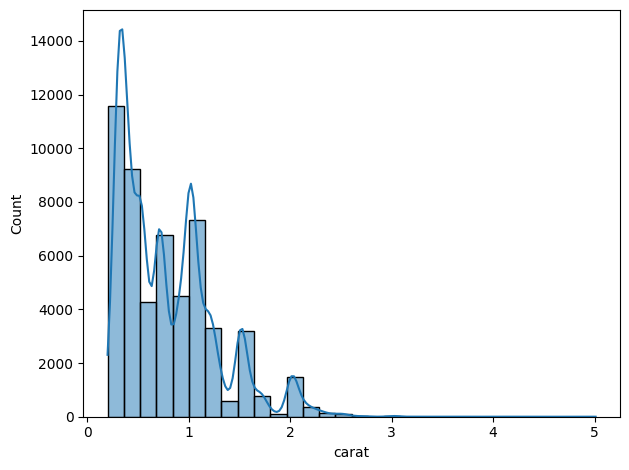

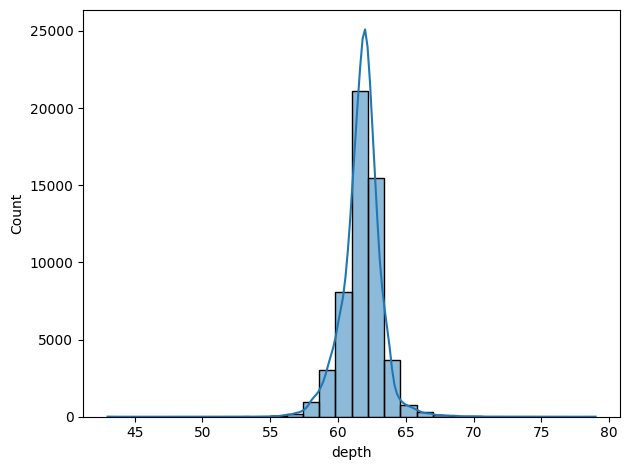

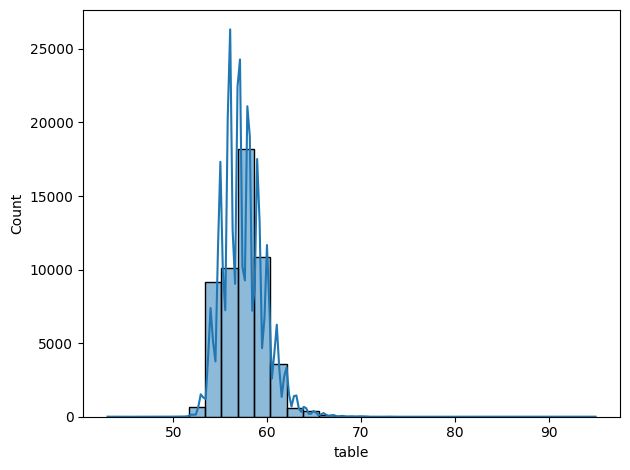

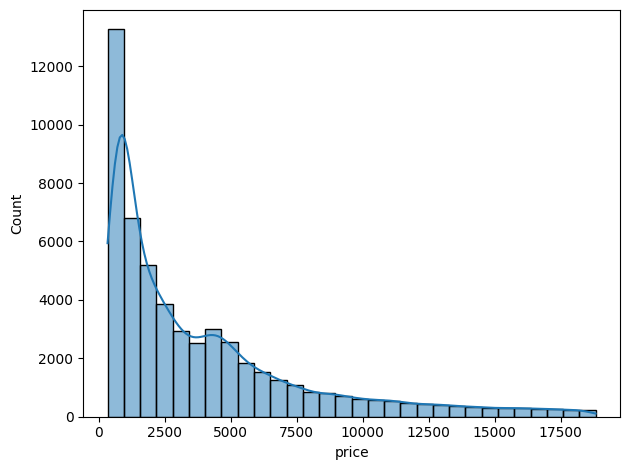

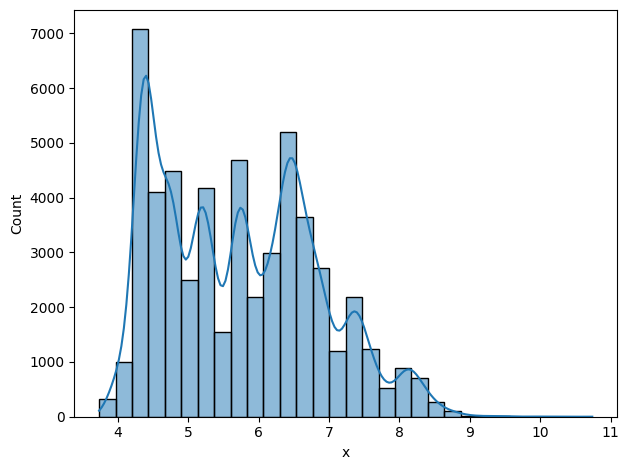

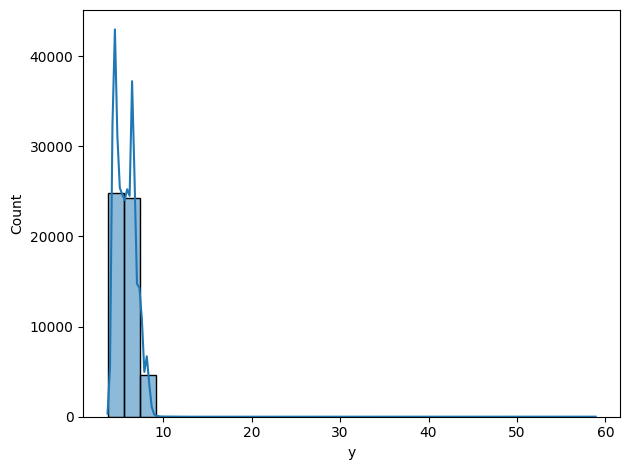

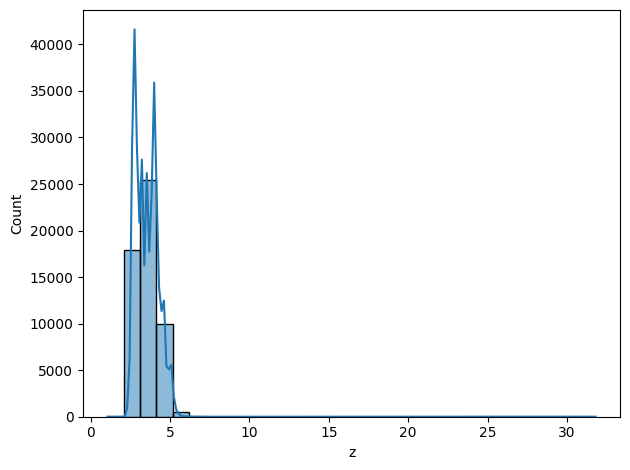

In [22]:
numcols=df.select_dtypes(include='number').columns
for col in numcols:
  sns.histplot(data=df,x=col,kde=True,bins=30)
  plt.tight_layout()
  plt.show()


In [23]:
df.select_dtypes(include='number').skew()

,0
carat,1.113218
depth,-0.113711
table,0.792069
price,1.618220
x,0.396908
y,2.470200
z,1.589309


only x and depth are normally distributed remaining all are skewed

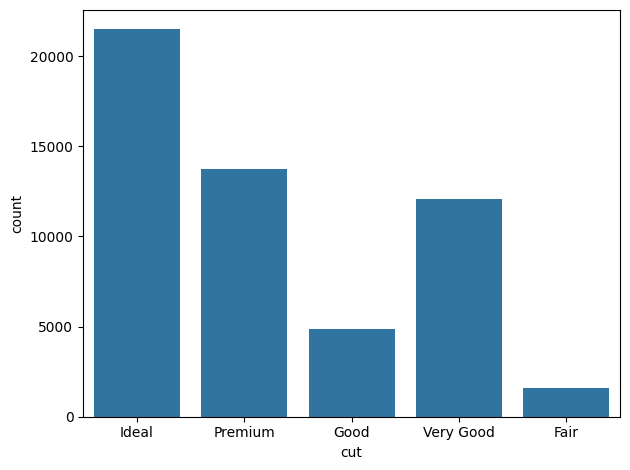

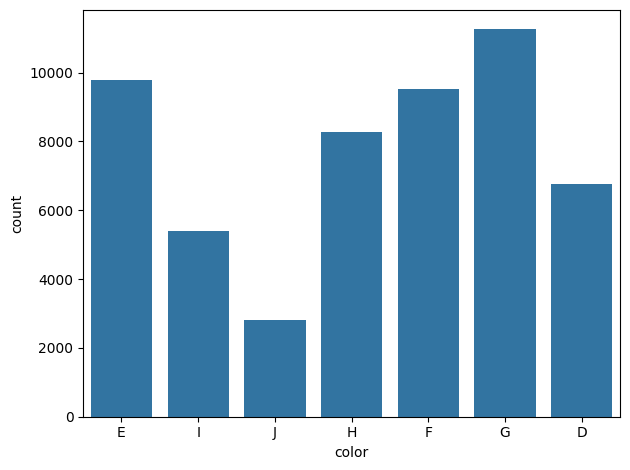

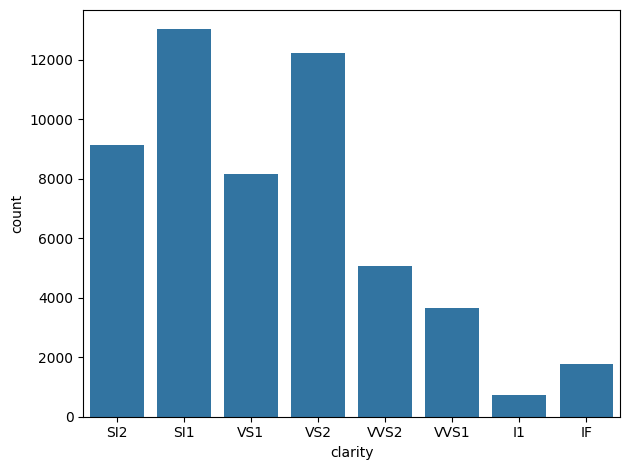

In [24]:
catcols=df.select_dtypes(include='object').columns
for col in catcols:
  sns.countplot(data=df,x=col)
  plt.tight_layout()
  plt.show()

In cut: ideal cut has the large no of diamonds followed by premium and very good

In color:people tend to buy G coloured forllowed by E,F

In clarity: SI1 and VS2 are most common clarities

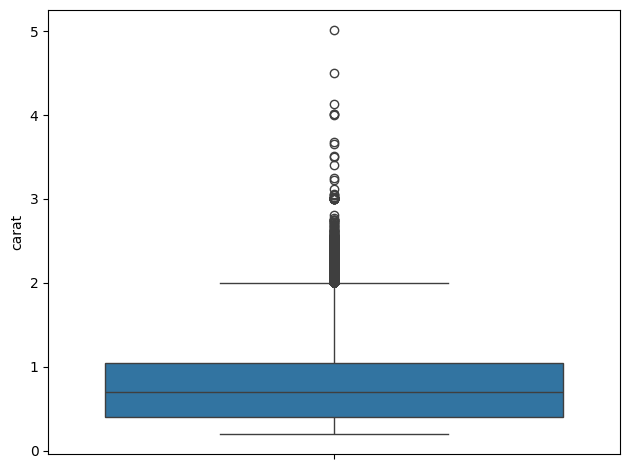

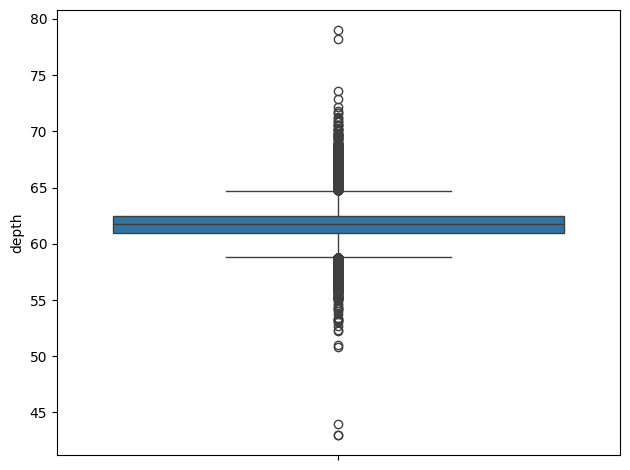

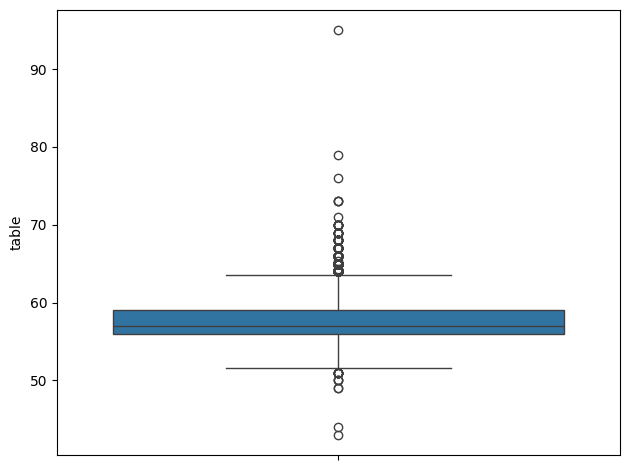

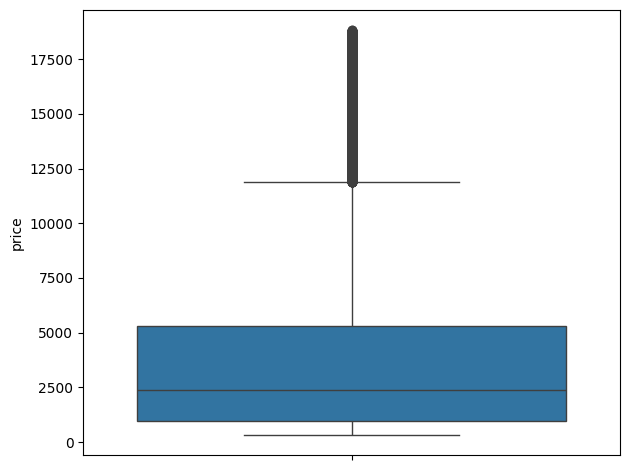

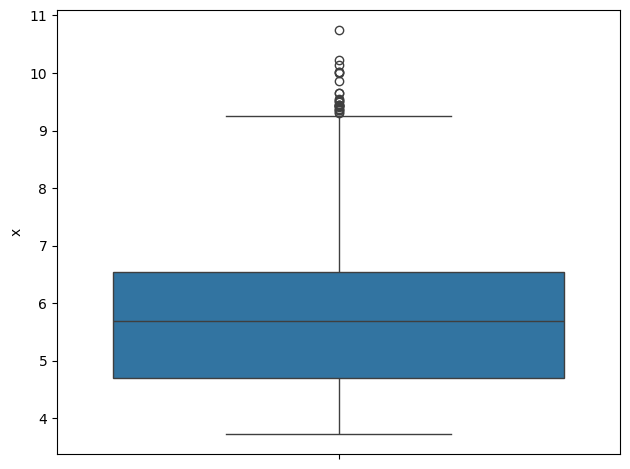

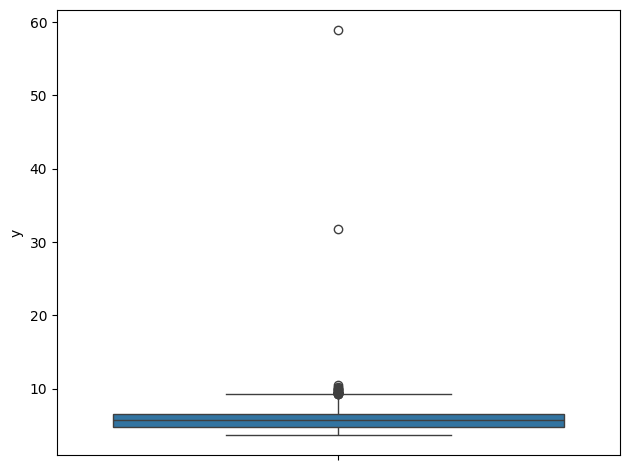

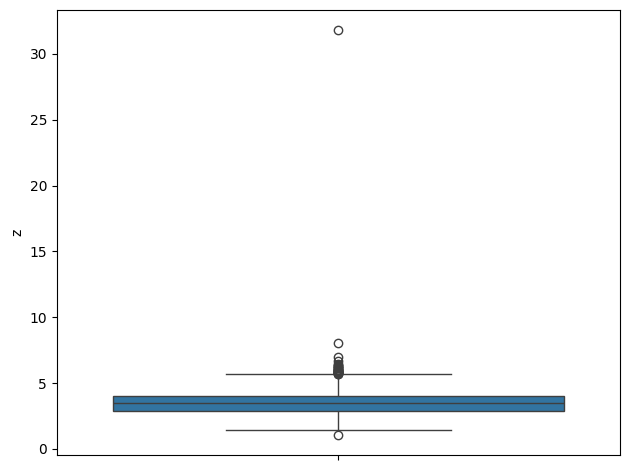

In [25]:
numcols=df.select_dtypes(include='number').columns
for col in numcols:
  sns.boxplot(y=df[col])
  plt.tight_layout()
  plt.show()

outliers are there in all features but high in y and z

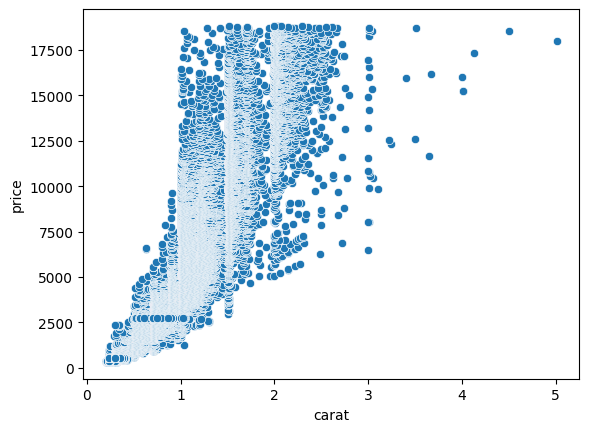

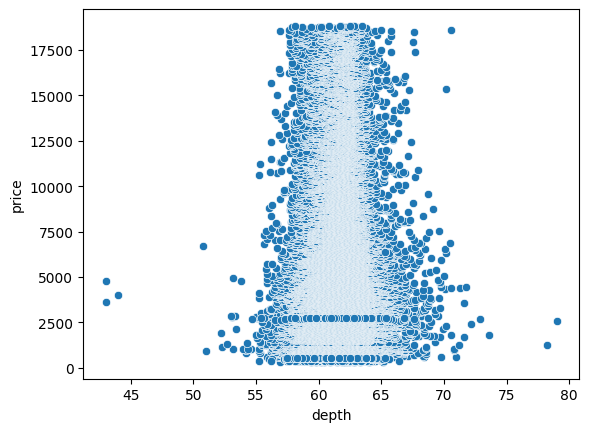

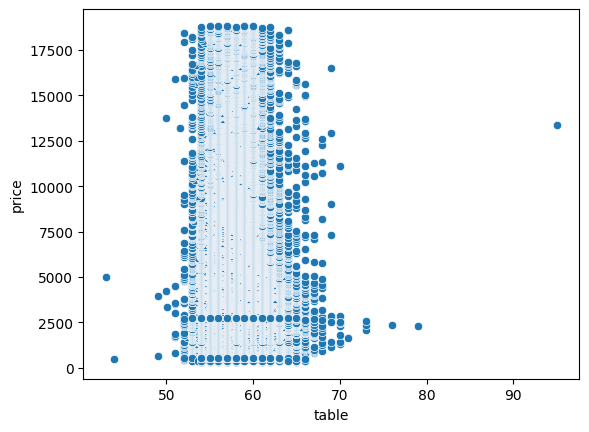

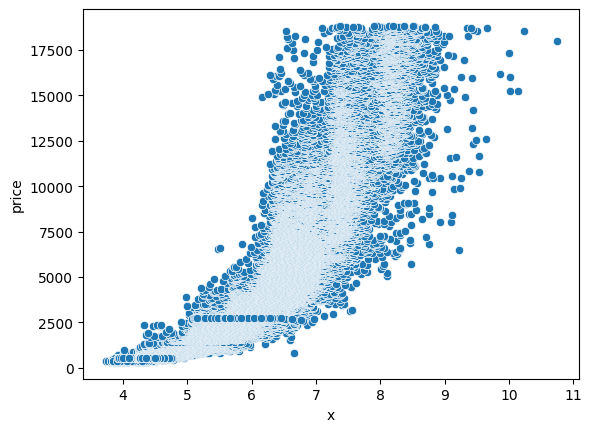

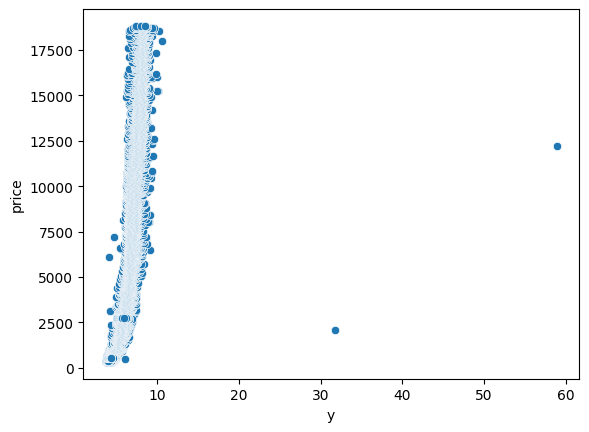

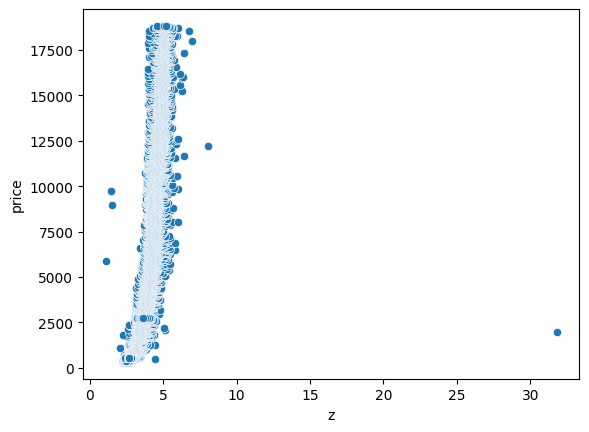

In [26]:
numcols=['carat','depth','table','x','y','z']
for col in numcols:
  sns.scatterplot(data=df,x=col,y='price')
  plt.show()

As carat weight increases price increased

price varied for similar depths(55 to 70).......soo depth wont make any impact on the price

table values are between(50 to 70) but prices are varied..soo no impact on price

price increased as x increases

y values are between 3 and 10 and probably there is a rice in the price same with z too

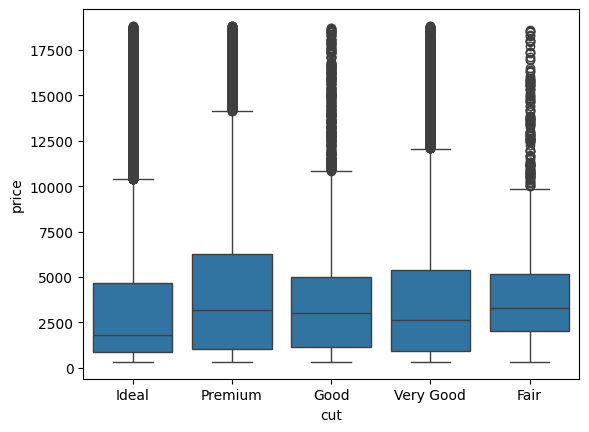

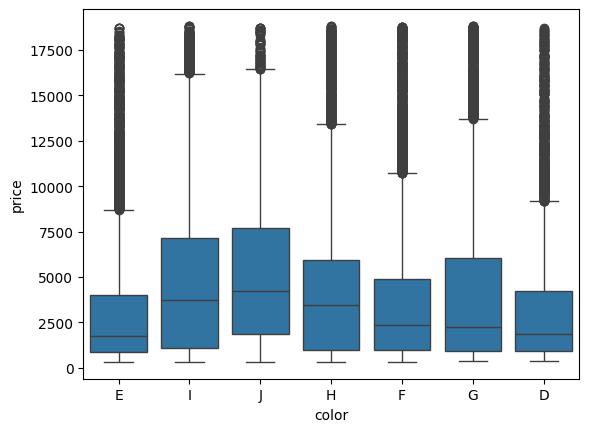

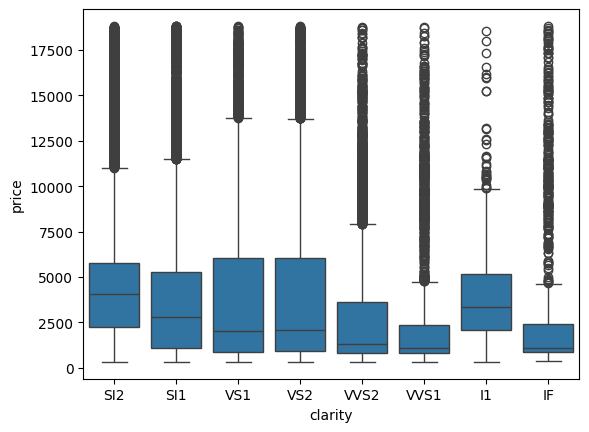

In [27]:
cat_cols=['cut','color','clarity']
for col in cat_cols:
  sns.boxplot(data=df,x=df[col],y='price')
  plt.show()

median prices for fair and premium are very high and for ideal cut it is low but people are buying the ideal cut and fair cut diamonds more

same with both two features also..in every step there are many buyers in high price in every feature


price may be determined by combined features because n single feature is ready to determine

multivariate

<Axes: >

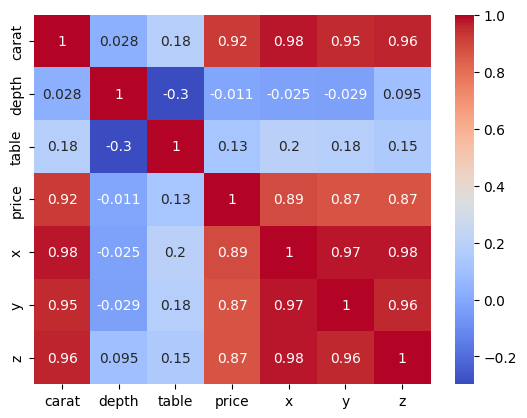

In [28]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')

for price there is a strong relationship with x,y,z and carat

in case of multicollinearity it is there for few of the features

#checking the outliers

In [29]:
def outlier_detection(col):
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  return ((df[col]<lower)|(df[col]>upper))

for col in df.select_dtypes(include='number').columns:
  print(col,outlier_detection(col).sum())

carat 1867
depth 2523
table 603
price 3520
x 24
y 22
z 29


carat,depth,table,price have high no of outliers which is valid because diamonds can be in that high range


x,y,z need to be checked to understand whether they are valid outliers or not

In [30]:
df.sort_values('x',ascending=False).head(15)

,carat,cut,color,clarity,depth,table,price,x,y,z
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03
24328,3.50,Ideal,H,I1,62.8,57.0,12587,9.65,9.59,6.03
22741,3.01,Fair,H,I1,56.1,62.0,10761,9.54,9.38,5.31


In [31]:
df.sort_values('y',ascending=False).head(15)

,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03


In [32]:
df.sort_values('z',ascending=False).head(15)

,carat,cut,color,clarity,depth,table,price,x,y,z
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
23644,3.65,Fair,H,I1,67.1,53.0,11668,9.53,9.48,6.38
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
26431,3.40,Fair,D,I1,66.8,52.0,15964,9.42,9.34,6.27
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17


x values are normal

y values are very high respective to other x and z in first 2 rows

z values are very high in first row which is not possible


i think 11 is the valid max value for x,y,z cols

In [33]:
df=df[(df['y']<20) & (df['z']<20)]

removed outliers

In [34]:
df.sort_values('x',ascending=False).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03
24328,3.50,Ideal,H,I1,62.8,57.0,12587,9.65,9.59,6.03
22741,3.01,Fair,H,I1,56.1,62.0,10761,9.54,9.38,5.31


In [35]:
df.sort_values('y',ascending=False).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03
24328,3.50,Ideal,H,I1,62.8,57.0,12587,9.65,9.59,6.03
23644,3.65,Fair,H,I1,67.1,53.0,11668,9.53,9.48,6.38


In [36]:
df.sort_values('z',ascending=False).head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
23644,3.65,Fair,H,I1,67.1,53.0,11668,9.53,9.48,6.38
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
26431,3.40,Fair,D,I1,66.8,52.0,15964,9.42,9.34,6.27
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
26194,2.01,Fair,G,SI2,65.6,56.0,15562,7.89,7.84,6.16
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13


checking for skweness

In [37]:
df.select_dtypes(include='number').skew()

,0
carat,1.113187
depth,-0.113681
table,0.792026
price,1.618291
x,0.396842
y,0.391330
z,0.391676


after removing outliers skewness removed for y,z

now only carat,price have highly pos skew and table has moderate

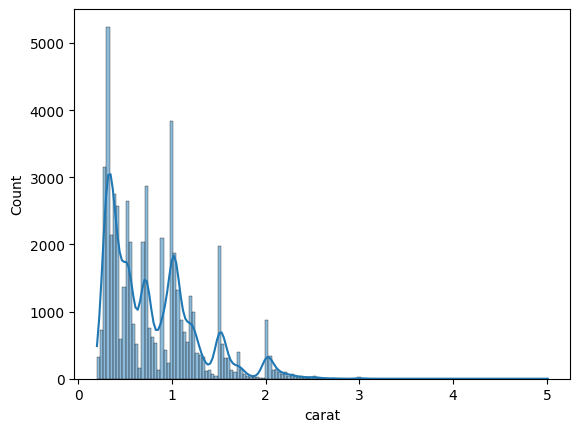

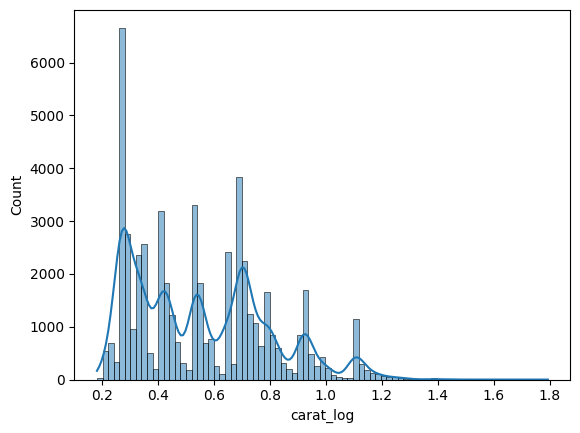

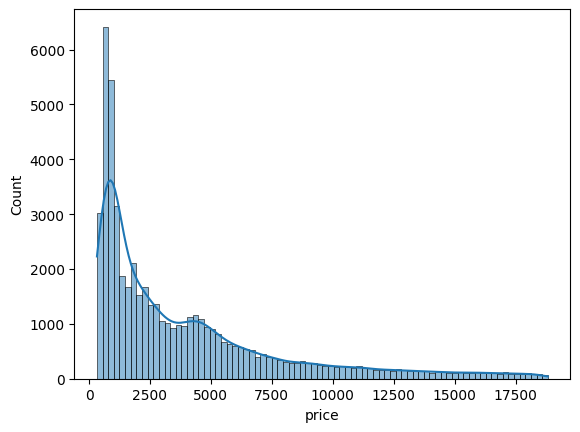

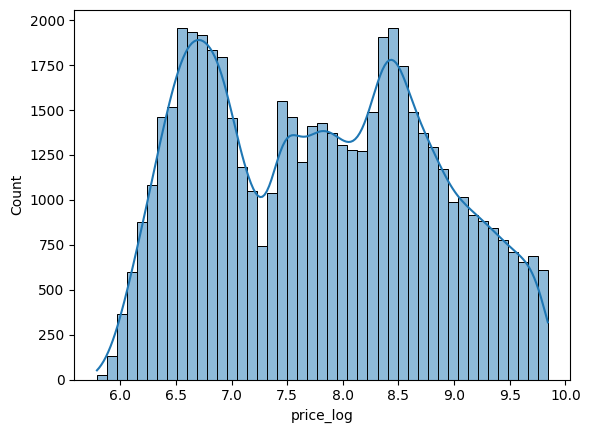

In [38]:
df['carat_log']=np.log1p(df['carat'])
df['price_log']=np.log1p(df['price'])

sns.histplot(df['carat'],kde=True)
plt.show()

sns.histplot(df['carat_log'],kde=True)
plt.show()

sns.histplot(df['price'],kde=True)
plt.show()

sns.histplot(df['price_log'],kde=True)
plt.show()



In [39]:
print(df[['carat','price','carat_log','price_log']].skew())

carat        1.113187
price        1.618291
carat_log    0.578619
price_log    0.115117
dtype: float64


there is a small difference of lessened skewness in carat_log  and there is a high reduction in price and in some case we can use log transformed data the distribution became more symmetric. The final decision should be based on evaluation metrics after training.

VIF for Multicollinearity

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X=df[['carat','depth','table','x','y','z']]

for i in range(len(X.columns)):
  print(X.columns[i],variance_inflation_factor(X.values,i))



carat 91.86878005555047
depth 914.445665675966
table 686.923875204643
x 11738.589875534613
y 10495.523715660507
z 3230.731909583277


In [41]:
df[['carat','depth','table','x','y','z']].corr()

,carat,depth,table,x,y,z
carat,1.000000,0.027987,0.181113,0.977856,0.976940,0.976527
depth,0.027987,1.000000,-0.297604,-0.025147,-0.028268,0.096397
table,0.181113,-0.297604,1.000000,0.195450,0.189267,0.155105
x,0.977856,-0.025147,0.195450,1.000000,0.998654,0.991090
y,0.976940,-0.028268,0.189267,0.998654,1.000000,0.990745
z,0.976527,0.096397,0.155105,0.991090,0.990745,1.000000


this matrix shows that there is a high correlation in between carat and its dimensions x,y,z

soo instead of removing them for linear models ill apply regularisation techniques because they are important features .

#ENCODING


encoding all the categorical will make all the features into numeric

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53772 entries, 0 to 53939
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53772 non-null  float64
 1   cut        53772 non-null  object 
 2   color      53772 non-null  object 
 3   clarity    53772 non-null  object 
 4   depth      53772 non-null  float64
 5   table      53772 non-null  float64
 6   price      53772 non-null  int64  
 7   x          53772 non-null  float64
 8   y          53772 non-null  float64
 9   z          53772 non-null  float64
 10  carat_log  53772 non-null  float64
 11  price_log  53772 non-null  float64
dtypes: float64(8), int64(1), object(3)
memory usage: 5.3+ MB


In [43]:
df.nunique()

,0
carat,273
cut,5
color,7
clarity,8
depth,184
table,127
price,11597
x,553
y,548
z,372


cut	5
color	7
clarity	8...and all these have natural order soo i preferably wanted to use ordinal encoding

In [44]:
for col in ['cut','color','clarity']:
  print(df[col].unique())

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


standard grading for diamonds
Cut:
Fair < Good < Very Good < Premium < Ideal

Color:
J < I < H < G < F < E < D

Clarity:
I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF

we shouldn't choose them just by unique because they can be only in alphabetical order

In [45]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder(categories=[ ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], ['J', 'I', 'H', 'G', 'F', 'E', 'D'], ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']])
df[['cut','color','clarity']]=encoder.fit_transform(df[['cut','color','clarity']])

In [46]:
for col in ['cut','color','clarity']:
  print(df[col].unique())

[4. 3. 1. 2. 0.]
[5. 1. 0. 2. 4. 3. 6.]
[1. 2. 4. 3. 5. 6. 0. 7.]


train test split

In [47]:
from sklearn.model_selection import train_test_split
X=df.drop(['price_log','price','carat_log'],axis=1)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

scaling

In [48]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scal=scaler.fit_transform(X_train)
X_test_scal=scaler.transform(X_test)

#Decision Tree

In [49]:
'''from sklearn.tree import DecisionTreeRegressor from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

best_score=-1 best_params=None

criteria=['squared_error','friedman_mse','absolute_error']

for c in criteria: for depth in range(3,11): for split in range(2,6): for leaf in range(1,4):

    dt=DecisionTreeRegressor(
        criterion=c,
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        random_state=1)

    dt.fit(X_train,y_train)

    X_pred=dt.predict(X_train)
    y_pred=dt.predict(X_test)

    Test_R2=r2_score(y_test,y_pred)

    if Test_R2 > best_score:
      best_score=Test_R2
      best_params=(c,depth,split,leaf)

      TrainR2 =r2_score(y_train,X_pred)
      MAE =mean_absolute_error(y_test,y_pred)
      MSE =mean_squared_error(y_test,y_pred)
      RMSE =np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Criterion : {best_params[0]}') print(f'DEPTH:{best_params[1]},Split:{best_params[2]},Leaf:{best_params[3]}') print("Train R2 ",TrainR2) print("Test R2 ",best_score) print("MAE ",MAE ) print("MSE ",MSE) print("RMSE ",RMSE)'''

'from sklearn.tree import DecisionTreeRegressor from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error\n\nbest_score=-1 best_params=None\n\ncriteria=[\'squared_error\',\'friedman_mse\',\'absolute_error\']\n\nfor c in criteria: for depth in range(3,11): for split in range(2,6): for leaf in range(1,4):\n\n    dt=DecisionTreeRegressor(\n        criterion=c,\n        max_depth=depth,\n        min_samples_split=split,\n        min_samples_leaf=leaf,\n        random_state=1)\n\n    dt.fit(X_train,y_train)\n\n    X_pred=dt.predict(X_train)\n    y_pred=dt.predict(X_test)\n\n    Test_R2=r2_score(y_test,y_pred)\n\n    if Test_R2 > best_score:\n      best_score=Test_R2\n      best_params=(c,depth,split,leaf)\n\n      TrainR2 =r2_score(y_train,X_pred)\n      MAE =mean_absolute_error(y_test,y_pred)\n      MSE =mean_squared_error(y_test,y_pred)\n      RMSE =np.sqrt(mean_squared_error(y_test,y_pred))\nprint(f\'Criterion : {best_params[0]}\') print(f\'DEPTH:{best_params[1]},Split:

In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

dt=DecisionTreeRegressor(criterion='squared_error',max_depth=10,min_samples_split=5,min_samples_leaf=
    5,random_state=1)

dt.fit(X_train,y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Train R2 :", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))
print("MAE :", mean_absolute_error(y_test, test_pred))
print("MSE :", mean_squared_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))



Train R2 : 0.9813919443080299
Test R2 : 0.973977721236099
MAE : 339.0277802046581
MSE : 408090.3805545426
RMSE : 638.8195211126086


As max_depth increased, the Test R² improved up to max_depth = 10. Beyond this point, the Test R² started decreasing while the Train R² continued increasing, indicating overfitting. Therefore, max_depth = 10 was selected as the optimal value.

#feature engineering

In [51]:
'''df['volume']=df['x']*df['y']*df['z']'''

"df['volume']=df['x']*df['y']*df['z']"

In [52]:
'''from sklearn.model_selection import train_test_split
X=df.drop(['price_log','price','carat_log'],axis=1)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)'''

"from sklearn.model_selection import train_test_split\nX=df.drop(['price_log','price','carat_log'],axis=1)\ny=df['price']\nX_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)"

In [53]:
'''from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

dt=DecisionTreeRegressor(criterion='squared_error',max_depth=10,min_samples_split=5,min_samples_leaf=
    5,random_state=1)

dt.fit(X_train,y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Train R2 :", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))
print("MAE :", mean_absolute_error(y_test, test_pred))
print("MSE :", mean_squared_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))'''

'from sklearn.tree import DecisionTreeRegressor\nfrom sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error\n\ndt=DecisionTreeRegressor(criterion=\'squared_error\',max_depth=10,min_samples_split=5,min_samples_leaf=\n    5,random_state=1)\n\ndt.fit(X_train,y_train)\n\ntrain_pred = dt.predict(X_train)\ntest_pred = dt.predict(X_test)\n\nprint("Train R2 :", r2_score(y_train, train_pred))\nprint("Test R2 :", r2_score(y_test, test_pred))\nprint("MAE :", mean_absolute_error(y_test, test_pred))\nprint("MSE :", mean_squared_error(y_test, test_pred))\nprint("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))'

A new feature, volume, was created using the diamond dimensions (x × y × z). After evaluating the model, it did not improve the overall performance. Therefore, the volume feature was excluded from the final model.

R² increased only because more features were added.

Adjusted R² decreased because those extra features didn't improve the model enough.

#feature imp

In [54]:
imp=pd.Series(dt.feature_importances_,index=X_train.columns)
imp=imp.sort_values(ascending=False)
print(imp)

carat      0.639006
y          0.262801
clarity    0.062028
color      0.031768
z          0.002076
x          0.001016
cut        0.000782
depth      0.000413
table      0.000111
dtype: float64


Carat was the most influential feature for predicting diamond price, followed by y

#LinearRegression
Assumptions:

Linearity,
Normality,
Homoscedasticity,
Independence,
Multicollinearity


Assumptions	 basic Check:

✅ Linearity..	Actual vs Predicted Plot (or scatter plots between predictors and target)

✅ Normality...	Residual Histogram + QQ Plot

✅ Homoscedasticity...Residual vs Predicted Plot

✅ Independence...Durbin–Watson Test

✅ Multicollinearity..VIF

In [55]:
'''from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scal,y_train)
train_pred=lr.predict(X_train_scal)
test_pred=lr.predict(X_test_scal)
print("Train pred ",r2_score(y_train,train_pred))
print("Test pred ",r2_score(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))'''

'from sklearn.linear_model import LinearRegression\nlr=LinearRegression()\nlr.fit(X_train_scal,y_train)\ntrain_pred=lr.predict(X_train_scal)\ntest_pred=lr.predict(X_test_scal)\nprint("Train pred ",r2_score(y_train,train_pred))\nprint("Test pred ",r2_score(y_test,test_pred))\nprint("MSE",mean_squared_error(y_test,test_pred))\nprint("MAE",mean_absolute_error(y_test,test_pred))\nprint("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))'

using logtransformed features

In [56]:
from sklearn.model_selection import train_test_split
X=df.drop(['price_log','price','carat'],axis=1)
y=df['price_log']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [57]:
scaler = StandardScaler()

X_train_scallog = scaler.fit_transform(X_train)
X_test_scallog = scaler.transform(X_test)
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scallog,y_train)
train_pred=lr.predict(X_train_scallog)
test_pred=lr.predict(X_test_scallog)
print("Train pred ",r2_score(y_train,train_pred))
print("Test pred ",r2_score(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))

Train pred  0.9741428408775332
Test pred  0.9723954509328295
MSE 0.02812327075784087
MAE 0.12505523489358591
RMSE 0.16769994262921162


Applying log transformation to the skewed variables (price and carat) significantly improved the Linear Regression model. The Test R² increased from 90.46% to 97.28%, indicating that the transformed data better satisfied the assumptions of Linear Regression and produced more accurate predictions.

Assumption checks

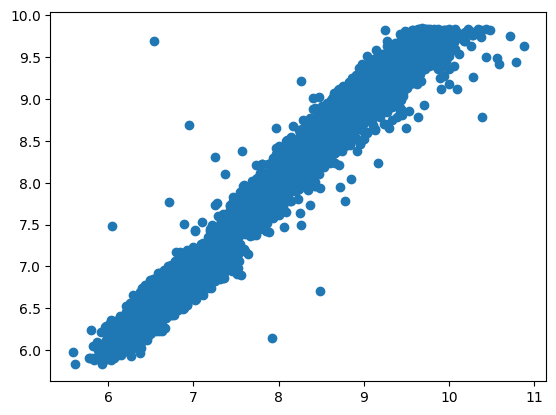

In [58]:
plt.scatter(test_pred,y_test)

Linearity:Only a few outliers show larger prediction errors, but the overall fit is excellent

<Axes: xlabel='price_log', ylabel='Count'>

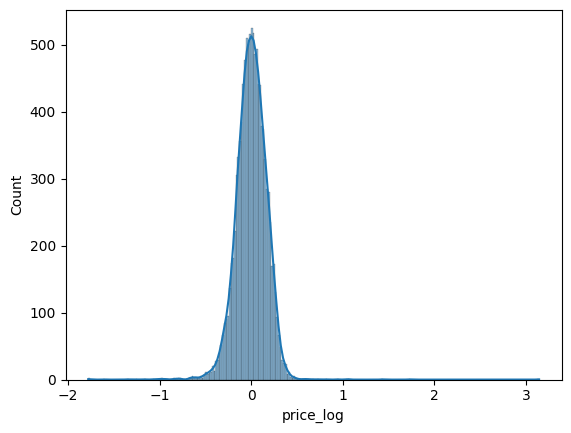

In [59]:
residuals=y_test - test_pred
sns.histplot(residuals,kde=True)

The residuals are approximately normally distributed with a bell-shaped curve centered around zero. This indicates normality

((array([-3.82856325, -3.60440645, -3.48138882, ...,  3.48138882,
          3.60440645,  3.82856325]),
  array([-1.77957998, -1.7758787 , -1.60980324, ...,  1.43619801,
          1.73325403,  3.14351079])),
 (np.float64(0.16223983921646803),
  np.float64(0.001666593893970351),
  np.float64(0.9671648966252955)))

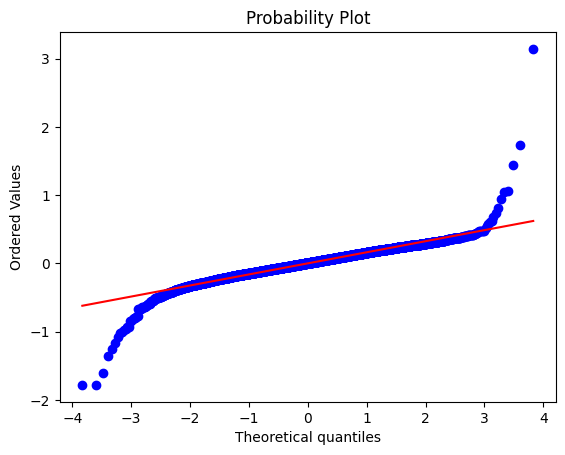

In [60]:
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=plt)

Most of the residuals are close to the reference line, which indicates that the residuals are approximately normally distributed. A few points at the ends deviate from the line, but the overall normality assumption is satisfied.

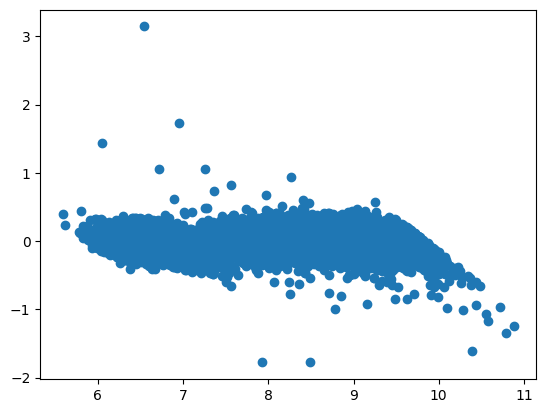

In [61]:
plt.scatter(test_pred, residuals)

Homoscedasticity means that the prediction errors (residuals) have a constant spread across all predicted values.  


The residuals are generally distributed around zero, but a slight trend is visible at higher predicted values, indicating minor heteroscedasticity. Despite this, the deviation is not severe, and the model still demonstrates good predictive performance.

In [62]:
from statsmodels.stats.stattools import durbin_watson
durbin_watson(residuals)

np.float64(2.0127223804504153)

values is in between (1.5 – 2.5) soo it indicates residuals are approximately independent

Log transformation improved the Linear Regression model by reducing skewness. The model achieved a Train R² of 97.42% and a Test R² of 97.28%, and all the Linear Regression assumptions were reasonably satisfied, indicating that the model is reliable for predicting diamond prices...[but there is a multicollinearity which is acceptable beacause they are imp features in this dataset]

#RandomForest

In [63]:
X=df.drop(['price','price_log','carat_log'],axis=1)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [64]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=1)

rf.fit(X_train,y_train)

train_pred=rf.predict(X_train)
test_pred=rf.predict(X_test)

print("Train R2:",r2_score(y_train,train_pred))
print("Test R2",r2_score(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))

Train R2: 0.997450803026649
Test R2 0.9805053403056324
MAE 271.7358272852051
MSE 305721.9994311972
RMSE 552.9213320457054


#GradientBoost

In [65]:
from sklearn.ensemble import GradientBoostingRegressor
gf=GradientBoostingRegressor(random_state=1)
gf.fit(X_train,y_train)
train_pred=gf.predict(X_train)
test_pred=gf.predict(X_test)
print("Train R2:",r2_score(y_train,train_pred))
print("Test R2",r2_score(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))

Train R2: 0.9779286514238805
Test R2 0.975542848321158
MAE 346.2424250510775
MSE 383545.5159962546
RMSE 619.3105166200995


#XGBoost

In [66]:
from xgboost import XGBRegressor
xg=XGBRegressor(random_state=1)
xg.fit(X_train,y_train)
train_pred=xg.predict(X_train)
test_pred=xg.predict(X_test)
print("Train R2:",r2_score(y_train,train_pred))
print("Test R2",r2_score(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))



Train R2: 0.9909020066261292
Test R2 0.9814900755882263
MAE 277.759765625
MSE 290278.8125
RMSE 538.775289429647


#CatBoost


In [67]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [68]:
from catboost import CatBoostRegressor
cb=CatBoostRegressor(random_state=1,verbose=0)
cb.fit(X_train,y_train)
train_pred=cb.predict(X_train)
test_pred=cb.predict(X_test)
print("Train R2:",r2_score(y_train,train_pred))
print("Test R2",r2_score(y_test,test_pred))
print("MAE",mean_absolute_error(y_test,test_pred))
print("MSE",mean_squared_error(y_test,test_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,test_pred)))

Train R2: 0.9884847939545189
Test R2 0.9824657956401212
MAE 272.65695859653516
MSE 274977.4604624753
RMSE 524.382933038896


#Tuning

In [69]:
from sklearn.model_selection import RandomizedSearchCV
models={
    "DecisionTree":dt,
    "RandomForest":rf,
    "GradientBoosting":gf,
    "XGBoost":xg,
    "CatBoost":cb
}
params={
    "DecisionTree":{
        "max_depth":[3,5,10,20,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4]

    },
    "RandomForest":{
        "n_estimators":[100,200,300],
        "max_depth":[10,20,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4]
    },
    "GradientBoosting":{
        "n_estimators":[100,200,300],
        "learning_rate":[0.01,0.1,0.5,1],
        "max_depth":[3,5,10],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4]
    },
    "XGBoost":{
        "n_estimators":[100,200,300],
        "learning_rate":[0.01,0.1,0.5,1],
        "max_depth":[3,5,7,10],
    },
    "CatBoost":{
        "iterations":[100,200,300],
        "learning_rate":[0.01,0.1,0.5,1],
        "depth":[3,5,7,10],
    }
    }


In [70]:

best_models={}
for name,model in models.items():
  random=RandomizedSearchCV(
      estimator=model,
      param_distributions=params[name],
      n_iter=10,
      cv=5,
      scoring='r2',
      random_state=1,
      n_jobs=-1,
      verbose=1
  )
  random.fit(X_train,y_train)
  best_models[name]=random.best_estimator_
  print("----------------------------------------")
  print(name)
  print("Best params ",random.best_params_)
  print("Best CV score ",random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------------------------------------
DecisionTree
Best params  {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Best CV score  0.9748986575627345
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------------------------------------
RandomForest
Best params  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV score  0.9814927317044804
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------------------------------------
GradientBoosting
Best params  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}
Best CV score  0.9821336693999575
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------------------------------------
XGBoost
Best params  {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}
Best CV score  0.9812125205993653
Fitting 5 folds for each of 10 can

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------------------------------------
CatBoost
Best params  {'learning_rate': 0.1, 'iterations': 300, 'depth': 7}
Best CV score  0.9825882709136848


In [71]:
for name, model in best_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)


    print(name)

    print("Train R2:", r2_score(y_train, train_pred))
    print("Test R2:", r2_score(y_test, test_pred))
    print("MAE:", mean_absolute_error(y_test, test_pred))
    print("MSE:", mean_squared_error(y_test, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

DecisionTree
Train R2: 0.9819418692942795
Test R2: 0.9741713952302257
MAE: 339.4803271740888
MSE: 405053.11795798934
RMSE: 636.4378351088104
RandomForest
Train R2: 0.995896544407556
Test R2: 0.9810261627768916
MAE: 269.7549398213995
MSE: 297554.28120690485
RMSE: 545.4853629630265
GradientBoosting
Train R2: 0.9860368079793929
Test R2: 0.9817188716470223
MAE: 283.4473398581465
MSE: 286690.9809944223
RMSE: 535.4353191510831
XGBoost
Train R2: 0.9983726143836975
Test R2: 0.9805316925048828
MAE: 268.1585693359375
MSE: 305308.34375
RMSE: 552.547141653995
CatBoost
Train R2: 0.98648218909009
Test R2: 0.9824544050340804
MAE: 278.7878981274006
MSE: 275156.0918881117
RMSE: 524.5532307479497


Hyperparameter tuning improved the performance of the tree-based models by selecting the best parameter combinations. Among all the tuned models, CatBoost achieved the best performance with a Train R² of 98.65%, Test R² of 98.25%, MAE of 278.79, and RMSE of 524.55, making it the final selected model.

#cross validation

In [72]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_models["CatBoost"],
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [0.83227405 0.84492708 0.74328938 0.40335337 0.79540315]
Mean R2: 0.7238494081649418
Standard Deviation: 0.16409221004047952


In [73]:
print(best_models["CatBoost"])
print(X.shape)
print(y.shape)
print(y.name)

CatBoostRegressor(depth=7, iterations=300, learning_rate=0.1, loss_function='RMSE', random_state=1, verbose=0)
(53772, 9)
(53772,)
price


In [74]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scores = cross_val_score(
    best_models["CatBoost"],
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

Scores: [0.98238056 0.98361963 0.98269458 0.98233881 0.98207628]
Mean: 0.9826219729175827
Std: 0.0005360643950873135


Cross-validation without shuffling produced inconsistent results because the data was split in its original order, leading to unbalanced folds. Using shuffled K-Fold created more representative folds and provided a reliable evaluation with a Mean R² of 98.26% and a Standard Deviation of 0.0005, confirming the model's stability and consistency.

#FeatureImportance

<Axes: >

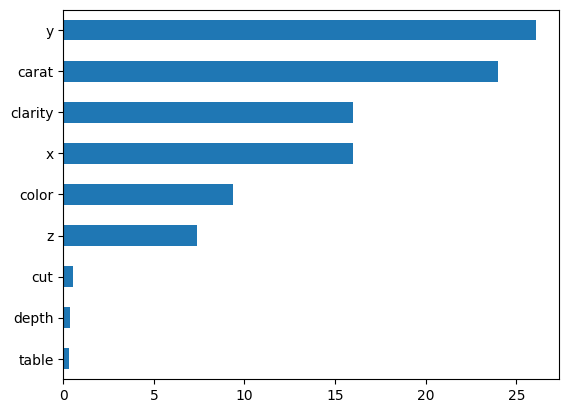

In [75]:
importance=pd.Series(best_models['CatBoost'].feature_importances_,index=X.columns)
importance.sort_values().plot(kind='barh')

This model identified y as slightly more important than carat. This is perfectly acceptable because feature importance is model-dependent. Earlier, the Decision Tree gave carat as the most important feature, whereas the tuned CatBoost model found y to contribute slightly more.

#ModelComparison

In [80]:
comparision=[]
for name,model in best_models.items():
  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)
  comparision.append({
      "Model":name,
      "Train R2" : r2_score(y_train,train_pred),
      "Test R2": r2_score(y_test,test_pred),
      "MAE": mean_absolute
      _error(y_test,test_pred),
      "MSE": mean_squared_error(y_test,test_pred),
      "RMSE":np.sqrt(mean_squared_error(y_test,test_pred))})
comparison_df=pd.DataFrame(comparision)
comparison_df.sort_values(by="Test R2",ascending=False).reset_index(drop=True)

,Model,Train R2,Test R2,MAE,MSE,RMSE
0,CatBoost,0.986482,0.982454,278.787898,275156.091888,524.553231
1,GradientBoosting,0.986037,0.981719,283.447340,286690.980994,535.435319
2,RandomForest,0.995897,0.981026,269.754940,297554.281207,545.485363
3,XGBoost,0.998373,0.980532,268.158569,305308.343750,552.547142
4,DecisionTree,0.981942,0.974171,339.480327,405053.117958,636.437835


CONCLUSION :

 In this project, a machine learning model was developed to predict diamond prices using the physical and quality-related features of diamonds. Initially, the dataset was cleaned by removing duplicate records, checking for missing values, removing invalid observations, and verifying the categorical values. Exploratory Data Analysis (EDA) was performed to understand the distribution of features, relationships with the target variable, and correlations among features. Outliers were investigated using the IQR method, and only unrealistic dimension values were removed while valid outliers were retained.

Skewness was analyzed, and log transformation was applied to the price and carat features to improve their distribution. Multicollinearity was checked using VIF, and categorical features (cut, color, and clarity) were converted into numerical values using Ordinal Encoding. The dataset was then split into training and testing sets, and feature scaling was applied for Linear Regression.

Several machine learning models, including Decision Tree, Linear Regression, Random Forest, Gradient Boosting, XGBoost, and CatBoost, were built and evaluated using Train R², Test R², MAE, MSE, and RMSE. For Linear Regression, the assumptions of linearity, normality, homoscedasticity, independence of residuals, and multicollinearity were checked. Hyperparameter tuning was performed using RandomizedSearchCV to improve the performance of the tree-based models. The final CatBoost model was validated using 5-fold shuffled K-Fold Cross-Validation, and feature importance was also analyzed to identify the most influential features.

Among all the models, the tuned CatBoost model achieved the best performance with a Train R² of 98.65%, Test R² of 98.25%, MAE of 278.79, MSE of 275156.09, and RMSE of 524.55. It also achieved a Mean Cross-Validation R² of 98.26% with a Standard Deviation of 0.0005, indicating that the model is accurate, stable, and reliable. Therefore, the tuned CatBoost model was selected as the final model for predicting diamond prices.